# NB_06 — Modelos supervisados y validación temporal

**Objetivo del notebook:** entrenar y evaluar modelos supervisados sobre el dataset generado en el NB_05.

Objetivos

1. Leer el dataset supervisado producido por el NB_05.
2. Usar únicamente columnas `feat_` como variables predictoras.
3. Excluir explícitamente columnas `outcome_`, porque contienen información futura.
4. Entrenar modelos supervisados con validación temporal.
5. Comparar modelos mediante métricas de clasificación y métricas de ranking.

## 1. Configuración de rutas


```text
../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip
```

Y guardará todas las salidas en:

```text
./outputs_nb06/
```

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Carpeta donde se está ejecutando el notebook.
# En Jupyter normalmente coincide con la carpeta donde está guardado el notebook.
NOTEBOOK_DIR = Path.cwd()

# Estructura esperada:
# JUNIO/NB_06  -> notebook actual
# JUNIO/NB_05/outputs_nb05 -> salidas del NB_05
NB05_OUTPUTS_DIR = NOTEBOOK_DIR.parent / "NB_05" / "outputs_nb05"

# Archivo de entrada principal generado por NB_05
INPUT_DATASET = NB05_OUTPUTS_DIR / "dataset_supervisado_tecnico_v1.csv.zip"

# Fallbacks por si ejecutas el notebook desde otra ubicación
candidate_inputs = [
    INPUT_DATASET,
    NOTEBOOK_DIR / "dataset_supervisado_tecnico_v1.csv.zip",
    NOTEBOOK_DIR / "outputs_nb05" / "dataset_supervisado_tecnico_v1.csv.zip",
    NOTEBOOK_DIR.parent / "outputs_nb05" / "dataset_supervisado_tecnico_v1.csv.zip",
]

INPUT_DATASET = None
for candidate in candidate_inputs:
    if candidate.exists():
        INPUT_DATASET = candidate
        break

if INPUT_DATASET is None:
    msg = "No se encontró dataset_supervisado_tecnico_v1.csv.zip. Revisa que NB_05/outputs_nb05 exista al mismo nivel que NB_06."
    raise FileNotFoundError(msg)

# Salidas del NB_06
OUTPUT_DIR = NOTEBOOK_DIR / "outputs_nb06"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("Archivo de entrada:", INPUT_DATASET)
print("Carpeta de salida:", OUTPUT_DIR)
print("Carpeta de figuras:", FIGURES_DIR)

NOTEBOOK_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_06
Archivo de entrada: /Users/rbr/TFM_MVP/JUNIO/NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip
Carpeta de salida: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06
Carpeta de figuras: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06/figures


## 2. Librerías

El notebook usa `scikit-learn` para los modelos base.  
Para XGBoost, intenta importar `xgboost`. Si no está instalado, el notebook sigue ejecutando los otros modelos y muestra una advertencia.

Si necesitas instalar XGBoost en tu entorno:

```bash
pip install xgboost
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

# Importación robusta de XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("ADVERTENCIA: XGBoost no está disponible en este entorno.")
    print("Detalle:", repr(e))

RANDOM_STATE = 42

# Configuración visual homogénea para figuras del TFM
# Criterio: alto contraste, fondo blanco, lectura clara en Word/PDF y sin mapas de color saturados.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "text.color": "#111111",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

COLOR_BAR = "#1f4e79"          # azul oscuro profesional
COLOR_BAR_ALT = "#4f81bd"      # azul medio
COLOR_GRID = "#d9d9d9"
COLOR_OK = "#d9ead3"           # verde claro, imprimible
COLOR_ERROR = "#f4cccc"        # rojo claro, imprimible
COLOR_NEUTRAL = "#f2f2f2"
COLOR_BORDER = "#333333"
COLOR_TEXT = "#111111"


## 3. Carga del dataset supervisado

El dataset del NB_05 tiene una fila por señal técnica candidata V4.

La variable objetivo principal será:

```text
target_combo_positive
```

donde:

```text
1 = la señal terminó con ret_combo > 0
0 = la señal terminó con ret_combo <= 0
```

In [3]:
df = pd.read_csv(INPUT_DATASET, compression="zip")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Años:", sorted(df["signal_year"].unique()))
print("Tickers:", df["ticker"].nunique())

TARGET_COL = "target_combo_positive"

if TARGET_COL not in df.columns:
    raise ValueError(f"No existe la columna target requerida: {TARGET_COL}")

print("\nBalance target principal:")
display(df[TARGET_COL].value_counts(dropna=False).rename("conteo").to_frame())
display((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).rename("porcentaje").to_frame())

Filas: 8155
Columnas: 76
Años: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Tickers: 502

Balance target principal:


,conteo
target_combo_positive,
0,4079
1,4076


,porcentaje
target_combo_positive,
0,50.02
1,49.98


## 4. Selección de features y control de leakage

Para entrenar modelos se usan columnas  `feat_`.

Quedan excluidas:

- `outcome_`: resultados futuros de la operación.
- `target_`: etiquetas supervisadas.
- identificadores como ticker, fecha o señal.
- cualquier variable posterior a la entrada.

Este control es central para evitar **leakage temporal**.

In [4]:
# Variables predictoras permitidas
feature_cols = [c for c in df.columns if c.startswith("feat_")]

# Columnas explícitamente excluidas
target_cols = [c for c in df.columns if c.startswith("target_")]
outcome_cols = [c for c in df.columns if c.startswith("outcome_")]
metadata_cols = [c for c in df.columns if c not in feature_cols + target_cols + outcome_cols]

# Remover features constantes o sin variación
constant_features = []
for c in feature_cols:
    if df[c].nunique(dropna=False) <= 1:
        constant_features.append(c)

feature_cols_model = [c for c in feature_cols if c not in constant_features]

print("Features originales:", len(feature_cols))
print("Features constantes eliminadas:", len(constant_features))
print("Features finales para modelado:", len(feature_cols_model))
print("Targets:", target_cols)
print("Outcomes excluidos:", outcome_cols)
print("Metadata no usada como predictor:", metadata_cols[:20], "...")

pd.DataFrame({
    "excluded_constant_features": constant_features
}).to_csv(OUTPUT_DIR / "constant_features_excluded_nb06.csv", index=False)

leakage_control = pd.DataFrame({
    "column": metadata_cols + target_cols + outcome_cols,
    "reason": (
        ["metadata_no_predictor"] * len(metadata_cols)
        + ["target_label"] * len(target_cols)
        + ["future_outcome_leakage"] * len(outcome_cols)
    )
})
leakage_control.to_csv(OUTPUT_DIR / "leakage_control_excluded_columns_nb06.csv", index=False)

display(leakage_control.head(15))

Features originales: 59
Features constantes eliminadas: 16
Features finales para modelado: 43
Targets: ['target_combo_positive', 'target_combo_ge_2pct', 'target_core_positive']
Outcomes excluidos: ['outcome_ret_combo', 'outcome_ret_core', 'outcome_ret_tactical', 'outcome_mfe', 'outcome_mae', 'outcome_duration_core_bars', 'outcome_negative_diagnosis']
Metadata no usada como predictor: ['signal_id', 'ticker', 'signal_date', 'entry_date', 'signal_year', 'signal_month', 'entry_execution_mode'] ...


,column,reason
0,signal_id,metadata_no_predictor
1,ticker,metadata_no_predictor
2,signal_date,metadata_no_predictor
3,entry_date,metadata_no_predictor
4,signal_year,metadata_no_predictor
5,signal_month,metadata_no_predictor
6,entry_execution_mode,metadata_no_predictor
7,target_combo_positive,target_label
8,target_combo_ge_2pct,target_label
9,target_core_positive,target_label


## 5. Tipos de variables y preprocesamiento

Se separan variables numéricas y categóricas.

El preprocesamiento aplica:

- imputación mediana para numéricas;
- escalado estándar para numéricas;
- imputación por moda para categóricas;
- one-hot encoding para categóricas.

In [5]:
X_all = df[feature_cols_model].copy()
y_all = df[TARGET_COL].astype(int).copy()

categorical_features = X_all.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = [c for c in feature_cols_model if c not in categorical_features]

print("Features numéricas:", len(numeric_features))
print("Features categóricas:", len(categorical_features))
print("Categóricas:", categorical_features)

# Compatibilidad con versiones distintas de scikit-learn
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

Features numéricas: 40
Features categóricas: 3
Categóricas: ['feat_entry_family', 'feat_tk_confirmation_status', 'feat_chikou_diagnostic_status']


## 6. Splits temporales walk-forward

No se usa split aleatorio porque sería metodológicamente débil en datos financieros.

Se definen tres folds temporales:

```text
Fold 1: Train 2018-2021 / Validation 2022 / Test 2023
Fold 2: Train 2018-2022 / Validation 2023 / Test 2024
Fold 3: Train 2018-2023 / Validation 2024 / Test 2025
```

La validación se usa para calibrar el umbral de decisión.  
El test queda reservado para evaluación fuera de muestra.

In [6]:
temporal_splits = [
    {
        "fold": 1,
        "train_years": [2018, 2019, 2020, 2021],
        "validation_year": 2022,
        "test_year": 2023,
    },
    {
        "fold": 2,
        "train_years": [2018, 2019, 2020, 2021, 2022],
        "validation_year": 2023,
        "test_year": 2024,
    },
    {
        "fold": 3,
        "train_years": [2018, 2019, 2020, 2021, 2022, 2023],
        "validation_year": 2024,
        "test_year": 2025,
    },
]

pd.DataFrame(temporal_splits).to_csv(OUTPUT_DIR / "temporal_splits_used_nb06.csv", index=False)
display(pd.DataFrame(temporal_splits))

,fold,train_years,validation_year,test_year
0,1,"[2018, 2019, 2020, 2021]",2022,2023
1,2,"[2018, 2019, 2020, 2021, 2022]",2023,2024
2,3,"[2018, 2019, 2020, 2021, 2022, 2023]",2024,2025


## 7. Definición de modelos

Se entrenan modelos con roles distintos:

| Modelo | Rol |
|---|---|
| Dummy Classifier | Control mínimo: baseline trivial. |
| Logistic Regression | Baseline interpretable. |
| Random Forest | Modelo no lineal comparativo. |
| XGBoost | Modelo principal para datos tabulares, si está instalado. |

Los hiperparámetros se mantienen moderados para evitar una búsqueda excesiva en esta fase.

In [7]:
models = {
    "Dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

hyperparams = []
for name, model in models.items():
    params = model.get_params()
    for k, v in params.items():
        if k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", 
                 "min_child_weight", "reg_lambda", "class_weight", "strategy", "max_iter",
                 "min_samples_leaf"]:
            hyperparams.append({"model": name, "hyperparameter": k, "value": v})

pd.DataFrame(hyperparams).to_csv(OUTPUT_DIR / "hyperparameters_nb06.csv", index=False)
display(pd.DataFrame(hyperparams))

,model,hyperparameter,value
0,Dummy_most_frequent,strategy,most_frequent
1,LogisticRegression,class_weight,balanced
2,LogisticRegression,max_iter,2000
3,RandomForest,class_weight,balanced
4,RandomForest,max_depth,5
5,RandomForest,min_samples_leaf,20
6,RandomForest,n_estimators,300
7,XGBoost,colsample_bytree,0.8
8,XGBoost,learning_rate,0.05
9,XGBoost,max_depth,3


## 8. Funciones auxiliares para la evaluación

Se calculan dos familias de métricas:

**Métricas de clasificación:**

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Brier score

**Métricas de ranking:**

- Precision@10%
- Precision@20%
- retorno medio de las señales top 10% y top 20%

La métrica de ranking es importante porque el sistema no necesariamente necesita clasificar perfectamente todas las señales: puede aportar valor si ordena mejor las oportunidades.

In [8]:
def find_best_threshold(y_true, y_proba, metric="f1"):
    """Calibra un umbral usando el set de validación."""
    thresholds = np.linspace(0.05, 0.95, 91)
    best_threshold = 0.5
    best_score = -np.inf

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        if score > best_score:
            best_score = score
            best_threshold = thr

    return float(best_threshold), float(best_score)


def compute_classification_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    try:
        roc_auc = roc_auc_score(y_true, y_proba)
    except Exception:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_proba)
    except Exception:
        pr_auc = np.nan

    try:
        brier = brier_score_loss(y_true, y_proba)
    except Exception:
        brier = np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "threshold": threshold,
    }


def compute_ranking_metrics(df_test, y_true, y_proba, outcome_col="outcome_ret_combo"):
    """Evalúa si el score ordena señales de mayor calidad."""
    temp = df_test.copy()
    temp["y_true"] = np.asarray(y_true)
    temp["score"] = np.asarray(y_proba)
    temp = temp.sort_values("score", ascending=False)

    results = {}
    for pct in [0.10, 0.20]:
        k = max(1, int(np.ceil(len(temp) * pct)))
        top = temp.head(k)
        suffix = f"top_{int(pct*100)}pct"

        results[f"n_{suffix}"] = k
        results[f"precision_{suffix}"] = top["y_true"].mean()

        if outcome_col in top.columns:
            results[f"mean_ret_combo_{suffix}"] = top[outcome_col].mean()
            results[f"sum_ret_combo_{suffix}"] = top[outcome_col].sum()
        else:
            results[f"mean_ret_combo_{suffix}"] = np.nan
            results[f"sum_ret_combo_{suffix}"] = np.nan

    return results

## 9. Entrenamiento walk-forward

Para cada fold:

1. Se entrena el modelo con años pasados.
2. Se calibra el umbral en el año de validación.
3. Se evalúa fuera de muestra en el año de test.

In [9]:
metrics_rows = []
ranking_rows = []
confusion_rows = []
predictions_rows = []
feature_importance_rows = []

for split in temporal_splits:
    fold = split["fold"]
    train_years = split["train_years"]
    validation_year = split["validation_year"]
    test_year = split["test_year"]

    train_mask = df["signal_year"].isin(train_years)
    val_mask = df["signal_year"].eq(validation_year)
    test_mask = df["signal_year"].eq(test_year)

    X_train = df.loc[train_mask, feature_cols_model]
    y_train = df.loc[train_mask, TARGET_COL].astype(int)

    X_val = df.loc[val_mask, feature_cols_model]
    y_val = df.loc[val_mask, TARGET_COL].astype(int)

    X_test = df.loc[test_mask, feature_cols_model]
    y_test = df.loc[test_mask, TARGET_COL].astype(int)
    df_test_meta = df.loc[test_mask].copy()

    print(f"\nFold {fold}: train={train_years}, validation={validation_year}, test={test_year}")
    print("Tamaños:", len(X_train), len(X_val), len(X_test))

    for model_name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ])

        pipe.fit(X_train, y_train)

        val_proba = pipe.predict_proba(X_val)[:, 1]
        test_proba = pipe.predict_proba(X_test)[:, 1]

        best_threshold, best_val_f1 = find_best_threshold(y_val, val_proba, metric="f1")
        metrics = compute_classification_metrics(y_test, test_proba, best_threshold)

        metrics_row = {
            "fold": fold,
            "model": model_name,
            "train_years": ",".join(map(str, train_years)),
            "validation_year": validation_year,
            "test_year": test_year,
            "n_train": len(X_train),
            "n_validation": len(X_val),
            "n_test": len(X_test),
            "validation_best_f1": best_val_f1,
            **metrics,
        }
        metrics_rows.append(metrics_row)

        ranking = compute_ranking_metrics(
            df_test=df_test_meta,
            y_true=y_test,
            y_proba=test_proba,
            outcome_col="outcome_ret_combo"
        )
        ranking_rows.append({
            "fold": fold,
            "model": model_name,
            "test_year": test_year,
            **ranking,
        })

        y_pred = (test_proba >= best_threshold).astype(int)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        confusion_rows.append({
            "fold": fold,
            "model": model_name,
            "test_year": test_year,
            "tn": int(cm[0, 0]),
            "fp": int(cm[0, 1]),
            "fn": int(cm[1, 0]),
            "tp": int(cm[1, 1]),
        })

        pred_temp = df_test_meta[["signal_id", "ticker", "signal_date", "entry_date", "signal_year", TARGET_COL, "outcome_ret_combo"]].copy()
        pred_temp["fold"] = fold
        pred_temp["model"] = model_name
        pred_temp["score"] = test_proba
        pred_temp["threshold"] = best_threshold
        pred_temp["predicted_label"] = y_pred
        predictions_rows.append(pred_temp)

        if model_name in ["RandomForest", "XGBoost"]:
            try:
                transformed_feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
                importances = pipe.named_steps["model"].feature_importances_
                imp_df = pd.DataFrame({
                    "fold": fold,
                    "model": model_name,
                    "feature": transformed_feature_names,
                    "importance": importances,
                })
                feature_importance_rows.append(imp_df)
            except Exception as e:
                print(f"No se pudo extraer importancia para {model_name} fold {fold}: {e}")

metrics_df = pd.DataFrame(metrics_rows)
ranking_df = pd.DataFrame(ranking_rows)
confusion_df = pd.DataFrame(confusion_rows)
predictions_df = pd.concat(predictions_rows, ignore_index=True)
feature_importance_df = pd.concat(feature_importance_rows, ignore_index=True) if feature_importance_rows else pd.DataFrame()

metrics_df.to_csv(OUTPUT_DIR / "ml_metrics_summary_nb06.csv", index=False)
ranking_df.to_csv(OUTPUT_DIR / "ranking_metrics_summary_nb06.csv", index=False)
confusion_df.to_csv(OUTPUT_DIR / "confusion_matrices_nb06.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "predictions_walkforward_nb06.csv.zip", index=False, compression="zip")

if not feature_importance_df.empty:
    feature_importance_df.to_csv(OUTPUT_DIR / "feature_importance_nb06.csv", index=False)

print("\nEntrenamiento finalizado.")
print("Archivos exportados en:", OUTPUT_DIR)


Fold 1: train=[2018, 2019, 2020, 2021], validation=2022, test=2023
Tamaños: 4423 472 907

Fold 2: train=[2018, 2019, 2020, 2021, 2022], validation=2023, test=2024
Tamaños: 4895 907 1429

Fold 3: train=[2018, 2019, 2020, 2021, 2022, 2023], validation=2024, test=2025
Tamaños: 5802 1429 924

Entrenamiento finalizado.
Archivos exportados en: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06


## 10. Resultados de métricas ML

Esta tabla resume el desempeño fuera de muestra por modelo y fold.

In [10]:
display(metrics_df.round(4))

metrics_mean = (
    metrics_df
    .groupby("model", as_index=False)
    [["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score"]]
    .mean()
    .sort_values("f1", ascending=False)
)

metrics_mean.to_csv(OUTPUT_DIR / "ml_metrics_mean_by_model_nb06.csv", index=False)
display(metrics_mean.round(4))

,fold,model,train_years,validation_year,test_year,n_train,n_validation,n_test,validation_best_f1,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,threshold
0,1,Dummy_most_frequent,"2018,2019,2020,2021",2022,2023,4423,472,907,0.4920,0.4509,0.4509,1.0000,0.6216,0.5000,0.4509,0.5491,0.05
1,1,LogisticRegression,"2018,2019,2020,2021",2022,2023,4423,472,907,0.5148,0.5061,0.4093,0.2152,0.2821,0.4721,0.4295,0.2555,0.53
2,1,RandomForest,"2018,2019,2020,2021",2022,2023,4423,472,907,0.4936,0.4509,0.4506,0.9927,0.6198,0.5933,0.5310,0.2506,0.41
3,1,XGBoost,"2018,2019,2020,2021",2022,2023,4423,472,907,0.4944,0.4564,0.4529,0.9878,0.6211,0.5163,0.4644,0.2630,0.23
4,2,Dummy_most_frequent,"2018,2019,2020,2021,2022",2023,2024,4895,907,1429,0.0000,0.4192,0.0000,0.0000,0.0000,0.5000,0.5808,0.5808,0.05
5,2,LogisticRegression,"2018,2019,2020,2021,2022",2023,2024,4895,907,1429,0.6221,0.5815,0.5812,1.0000,0.7352,0.5377,0.6139,0.2522,0.11
6,2,RandomForest,"2018,2019,2020,2021,2022",2023,2024,4895,907,1429,0.6221,0.5808,0.5808,1.0000,0.7348,0.5561,0.6188,0.2444,0.37
7,2,XGBoost,"2018,2019,2020,2021,2022",2023,2024,4895,907,1429,0.6221,0.5808,0.5808,1.0000,0.7348,0.5377,0.6073,0.2506,0.13
8,3,Dummy_most_frequent,"2018,2019,2020,2021,2022,2023",2024,2025,5802,1429,924,0.0000,0.5087,0.0000,0.0000,0.0000,0.5000,0.4913,0.4913,0.05
9,3,LogisticRegression,"2018,2019,2020,2021,2022,2023",2024,2025,5802,1429,924,0.7352,0.4924,0.4919,1.0000,0.6594,0.5722,0.5471,0.2466,0.17


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
3,XGBoost,0.5103,0.5087,0.9959,0.6719,0.5172,0.5274,0.2579
2,RandomForest,0.5091,0.5083,0.9976,0.6718,0.5734,0.5696,0.2473
1,LogisticRegression,0.5267,0.4941,0.7384,0.5589,0.5273,0.5301,0.2514
0,Dummy_most_frequent,0.4596,0.1503,0.3333,0.2072,0.5000,0.5077,0.5404


## 11. Resultados de ranking

Aquí se busca observar si los modelos ordenan mejor las señales.

Una señal positiva sería que el top 10% o top 20% tenga mayor precisión que el promedio general del año.

In [11]:
display(ranking_df.round(4))

ranking_mean = (
    ranking_df
    .groupby("model", as_index=False)
    [["precision_top_10pct", "precision_top_20pct", "mean_ret_combo_top_10pct", "mean_ret_combo_top_20pct"]]
    .mean()
    .sort_values("precision_top_10pct", ascending=False)
)

ranking_mean.to_csv(OUTPUT_DIR / "ranking_metrics_mean_by_model_nb06.csv", index=False)
display(ranking_mean.round(4))

,fold,model,test_year,n_top_10pct,precision_top_10pct,mean_ret_combo_top_10pct,sum_ret_combo_top_10pct,n_top_20pct,precision_top_20pct,mean_ret_combo_top_20pct,sum_ret_combo_top_20pct
0,1,Dummy_most_frequent,2023,91,0.2747,-0.0315,-2.8676,182,0.2692,-0.0299,-5.4463
1,1,LogisticRegression,2023,91,0.3846,-0.0094,-0.8548,182,0.3956,-0.0024,-0.4441
2,1,RandomForest,2023,91,0.5824,0.0440,4.0081,182,0.5934,0.0383,6.9725
3,1,XGBoost,2023,91,0.4725,0.0141,1.2863,182,0.4560,0.0142,2.5774
4,2,Dummy_most_frequent,2024,143,0.5594,0.0164,2.3403,286,0.5699,0.0147,4.2001
5,2,LogisticRegression,2024,143,0.6364,0.0409,5.8416,286,0.6119,0.0367,10.4932
6,2,RandomForest,2024,143,0.6434,0.0538,7.6894,286,0.6224,0.0470,13.4331
7,2,XGBoost,2024,143,0.6294,0.0443,6.3385,286,0.6259,0.0415,11.8631
8,3,Dummy_most_frequent,2025,93,0.5591,0.0548,5.0995,185,0.5243,0.0483,8.9303
9,3,LogisticRegression,2025,93,0.6129,0.1220,11.3415,185,0.5514,0.0810,14.9867


,model,precision_top_10pct,precision_top_20pct,mean_ret_combo_top_10pct,mean_ret_combo_top_20pct
2,RandomForest,0.6129,0.5926,0.0673,0.0540
3,XGBoost,0.5537,0.5264,0.0394,0.0281
1,LogisticRegression,0.5446,0.5196,0.0511,0.0384
0,Dummy_most_frequent,0.4644,0.4545,0.0132,0.0110


## 12. Matrices de confusión

Las matrices de confusión permiten ver cuántas señales se aprueban o descartan correctamente bajo el umbral calibrado en validación.

In [12]:
display(confusion_df)

,fold,model,test_year,tn,fp,fn,tp
0,1,Dummy_most_frequent,2023,0,498,0,409
1,1,LogisticRegression,2023,371,127,321,88
2,1,RandomForest,2023,3,495,3,406
3,1,XGBoost,2023,10,488,5,404
4,2,Dummy_most_frequent,2024,599,0,830,0
5,2,LogisticRegression,2024,1,598,0,830
6,2,RandomForest,2024,0,599,0,830
7,2,XGBoost,2024,0,599,0,830
8,3,Dummy_most_frequent,2025,470,0,454,0
9,3,LogisticRegression,2025,1,469,0,454


## 12.1 Matrices de confusión visibles en el notebook

En esta versión las matrices de confusión se muestran explícitamente dentro del notebook, no solo como archivos exportados.

Se generan dos niveles de visualización:

1. **Matriz agregada por modelo**, sumando todos los folds de test. Esta es la vista principal para comparar modelos.
2. **Matrices por fold**, una figura por fold con todos los modelos evaluados en ese año de test.

La lectura de cada matriz es:

- **TN**: señales realmente negativas que el modelo descartó correctamente.
- **FP**: señales negativas que el modelo aprobó erróneamente.
- **FN**: señales positivas que el modelo descartó.
- **TP**: señales positivas que el modelo aprobó correctamente.

Para mantener legibilidad en Word/PDF, no se usa mapa de calor saturado. Se usa fondo blanco, bordes oscuros, verde claro para aciertos y rojo claro para errores.

Matriz de confusión agregada por modelo


,model,tn,fp,fn,tp,total,accuracy_from_cm,precision_from_cm,recall_from_cm
0,Dummy_most_frequent,1069,498,1284,409,3260,0.4534,0.4509,0.2416
1,LogisticRegression,373,1194,321,1372,3260,0.5353,0.5347,0.8104
2,RandomForest,7,1560,3,1690,3260,0.5206,0.5200,0.9982
3,XGBoost,12,1555,5,1688,3260,0.5215,0.5205,0.9970


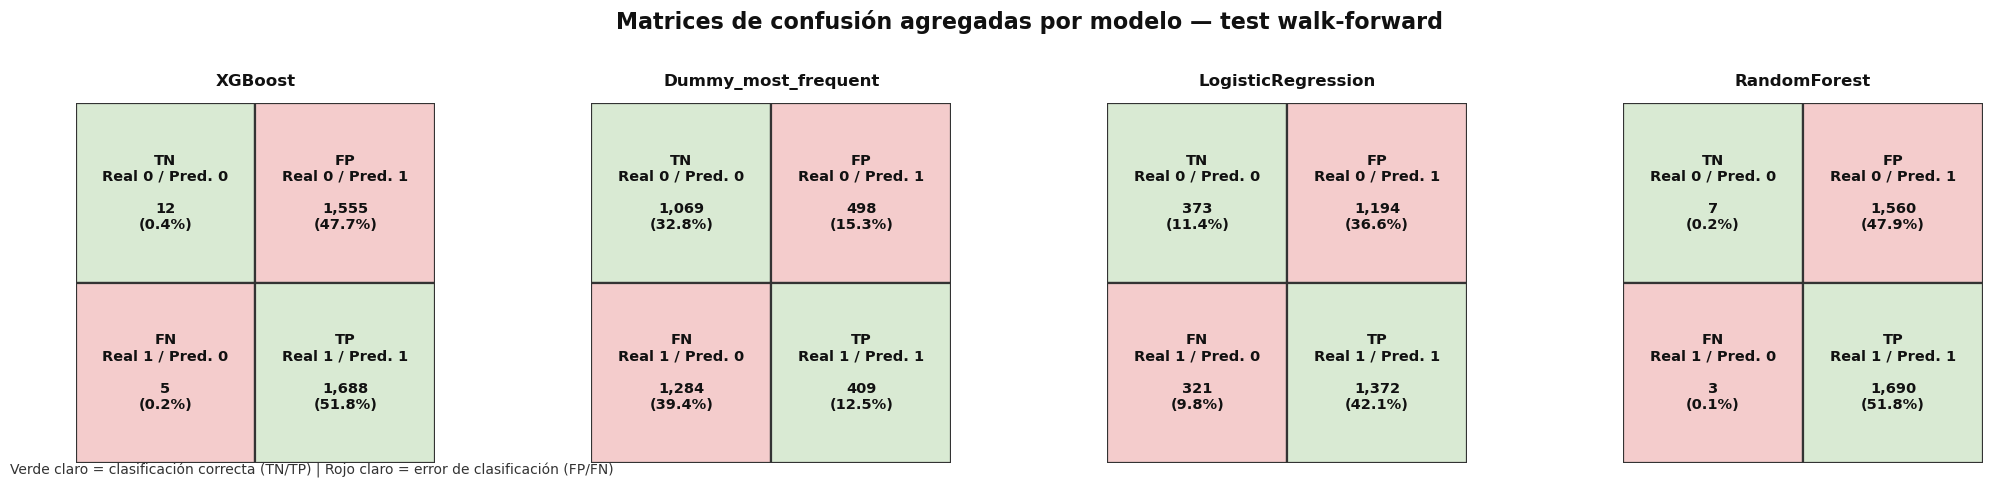

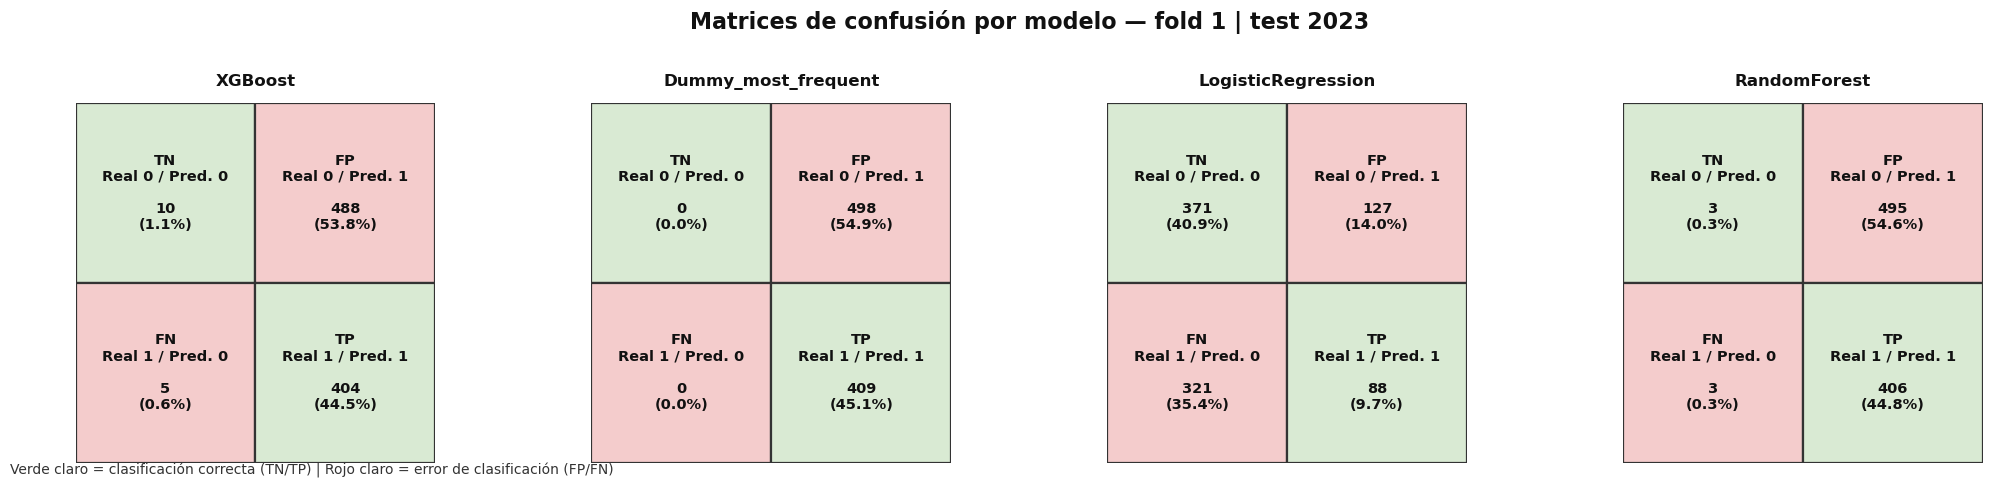

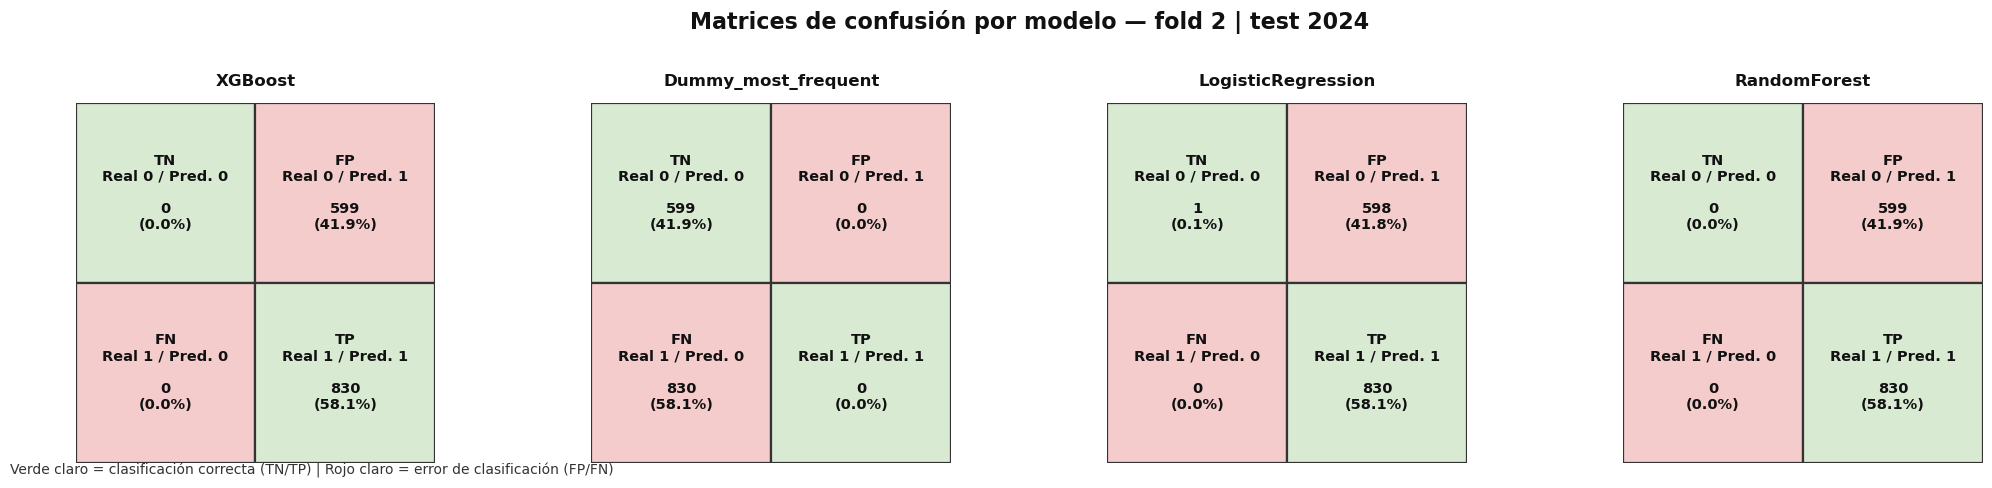

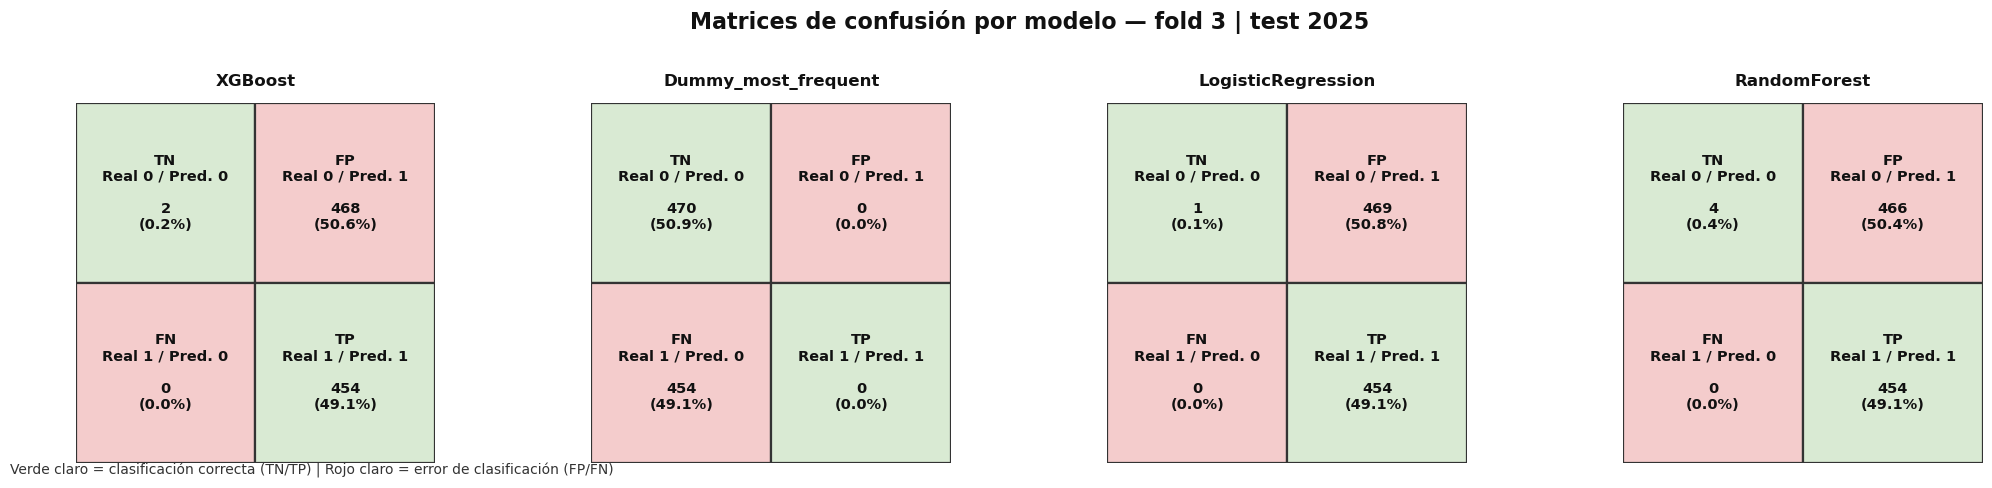

Matrices de confusión visibles en notebook y exportadas en: /Users/rbr/TFM_MVP/JUNIO/NB_06/outputs_nb06/figures/confusion_matrices


In [13]:
# Matrices de confusión visibles: agregadas y por fold
from pathlib import Path
from matplotlib.patches import Rectangle
import re

CONFUSION_DIR = FIGURES_DIR / "confusion_matrices"
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

# Tabla agregada por modelo: suma TN/FP/FN/TP de todos los folds de test
confusion_agg = (
    confusion_df
    .groupby("model", as_index=False)[["tn", "fp", "fn", "tp"]]
    .sum()
)
confusion_agg["total"] = confusion_agg[["tn", "fp", "fn", "tp"]].sum(axis=1)
confusion_agg["accuracy_from_cm"] = (confusion_agg["tn"] + confusion_agg["tp"]) / confusion_agg["total"]
confusion_agg["precision_from_cm"] = confusion_agg["tp"] / (confusion_agg["tp"] + confusion_agg["fp"]).replace(0, np.nan)
confusion_agg["recall_from_cm"] = confusion_agg["tp"] / (confusion_agg["tp"] + confusion_agg["fn"]).replace(0, np.nan)
confusion_agg.to_csv(OUTPUT_DIR / "confusion_matrices_aggregated_by_model_nb06.csv", index=False)

print("Matriz de confusión agregada por modelo")
display(confusion_agg.round(4))

# Funciones auxiliares de visualización profesional.
def _safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text)).strip("_")


def draw_confusion_matrix_on_axis(ax, cm_values, title):
    cm = np.array(cm_values, dtype=int)
    labels = np.array([[
        "TN\nReal 0 / Pred. 0",
        "FP\nReal 0 / Pred. 1"
    ], [
        "FN\nReal 1 / Pred. 0",
        "TP\nReal 1 / Pred. 1"
    ]])
    cell_colors = np.array([[COLOR_OK, COLOR_ERROR], [COLOR_ERROR, COLOR_OK]])

    total = cm.sum()
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.invert_yaxis()
    ax.set_aspect("equal")

    for i in range(2):
        for j in range(2):
            ax.add_patch(
                Rectangle(
                    (j, i), 1, 1,
                    facecolor=cell_colors[i, j],
                    edgecolor=COLOR_BORDER,
                    linewidth=1.6
                )
            )
            value = int(cm[i, j])
            pct = value / total if total else 0
            ax.text(
                j + 0.5, i + 0.5,
                f"{labels[i, j]}\n\n{value:,}\n({pct:.1%})",
                ha="center",
                va="center",
                fontsize=10.5,
                color=COLOR_TEXT,
                fontweight="bold"
            )

    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["Pred. 0\nfracaso", "Pred. 1\néxito"], fontsize=9.5)
    ax.set_yticklabels(["Real 0\nfracaso", "Real 1\néxito"], fontsize=9.5)
    ax.tick_params(length=0)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_confusion_grid(rows_df, title, save_path, model_order=None):
    if model_order is None:
        model_order = list(rows_df["model"].drop_duplicates())
    n = len(model_order)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for idx, model_name in enumerate(model_order):
        ax = axes[idx]
        row = rows_df.loc[rows_df["model"].eq(model_name)]
        if row.empty:
            ax.set_title(f"{model_name}\nSin datos", fontsize=12)
            continue
        row = row.iloc[0]
        cm_values = [[row["tn"], row["fp"]], [row["fn"], row["tp"]]]
        draw_confusion_matrix_on_axis(ax, cm_values, str(model_name))

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    fig.text(
        0.01, 0.01,
        "Verde claro = clasificación correcta (TN/TP) | Rojo claro = error de clasificación (FP/FN)",
        fontsize=10,
        color="#333333"
    )
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()


# Orden estable de modelos, para que todos los gráficos salgan comparables.
preferred_model_order = [
    "Dummy_Most_Frequent",
    "Logistic_Regression",
    "Random_Forest",
    "XGBoost"
]
model_order = [m for m in preferred_model_order if m in confusion_df["model"].unique()]
model_order += [m for m in confusion_df["model"].unique() if m not in model_order]

# 1) Vista principal: matrices agregadas por modelo en una sola figura.
plot_confusion_grid(
    confusion_agg,
    title="Matrices de confusión agregadas por modelo — test walk-forward",
    save_path=CONFUSION_DIR / "fig_nb06_confusion_aggregated_all_models.png",
    model_order=model_order
)

# 2) Vista por fold: una figura por año de test, con todos los modelos en la misma imagen.
for fold in sorted(confusion_df["fold"].unique()):
    fold_df = confusion_df.loc[confusion_df["fold"].eq(fold)].copy()
    test_year = fold_df["test_year"].iloc[0]
    plot_confusion_grid(
        fold_df,
        title=f"Matrices de confusión por modelo — fold {fold} | test {test_year}",
        save_path=CONFUSION_DIR / f"fig_nb06_confusion_fold{fold}_all_models_test{test_year}.png",
        model_order=model_order
    )

# 3) Además se exportan matrices individuales, por si se necesitan para el documento.
def plot_single_confusion_matrix(cm_values, title, save_path):
    fig, ax = plt.subplots(figsize=(7.2, 5.8))
    draw_confusion_matrix_on_axis(ax, cm_values, title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.close(fig)

for _, row in confusion_agg.iterrows():
    model_name = row["model"]
    cm_values = [[row["tn"], row["fp"]], [row["fn"], row["tp"]]]
    plot_single_confusion_matrix(
        cm_values,
        title=f"Matriz agregada — {model_name}",
        save_path=CONFUSION_DIR / f"fig_nb06_confusion_aggregated_{_safe_filename(model_name)}.png"
    )

for _, row in confusion_df.iterrows():
    model_name = row["model"]
    fold = row["fold"]
    test_year = row["test_year"]
    cm_values = [[row["tn"], row["fp"]], [row["fn"], row["tp"]]]
    plot_single_confusion_matrix(
        cm_values,
        title=f"Matriz — {model_name} | fold {fold} | test {test_year}",
        save_path=CONFUSION_DIR / f"fig_nb06_confusion_fold{fold}_{_safe_filename(model_name)}_test{test_year}.png"
    )

print("Matrices de confusión visibles en notebook y exportadas en:", CONFUSION_DIR)


## 13. Figuras descriptivas

Se generan figuras básicas para el TFM.

Nota metodológica: las curvas financieras y backtests con score de modelo se dejan para el NB_07.  
Aquí solo se reportan métricas de machine learning y ranking.

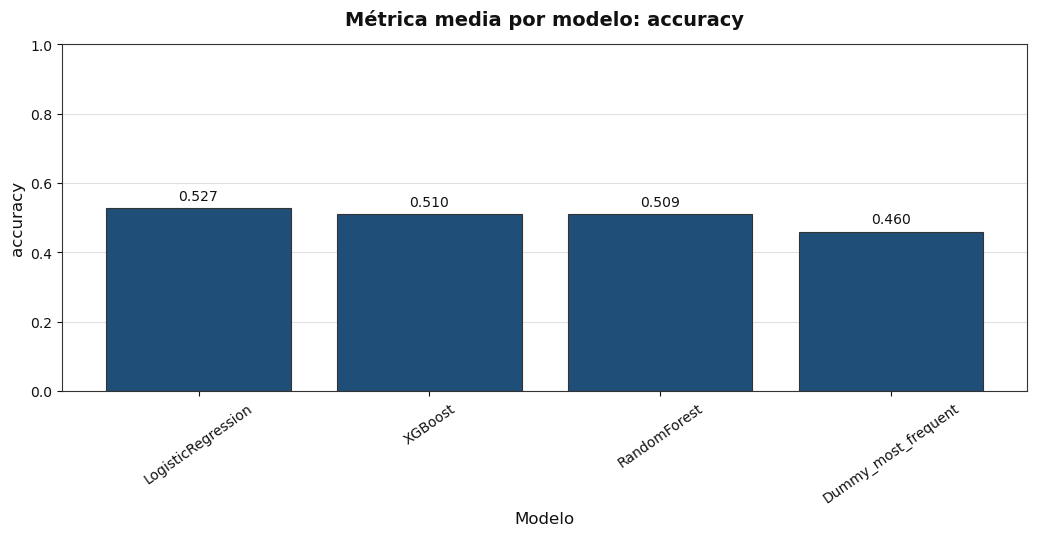

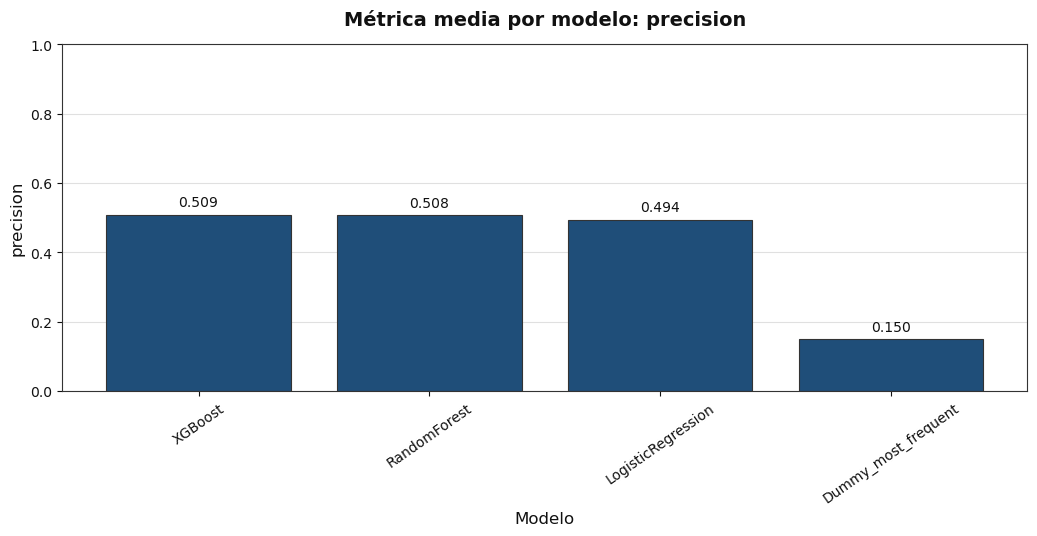

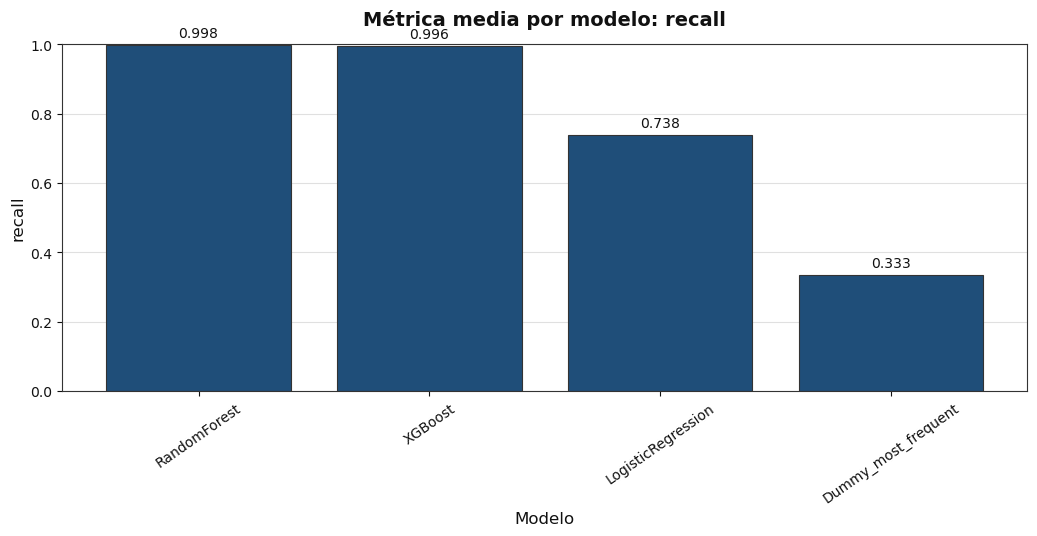

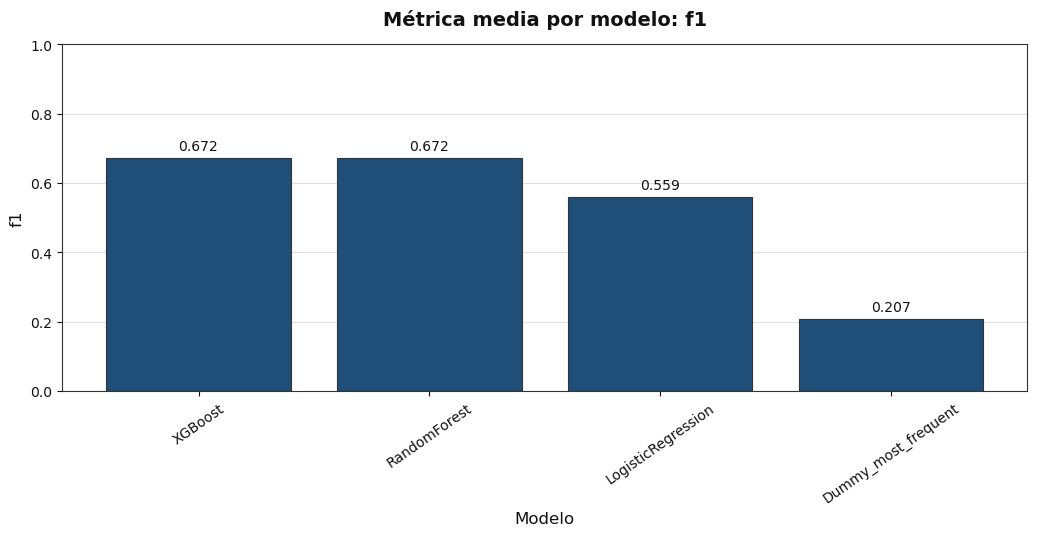

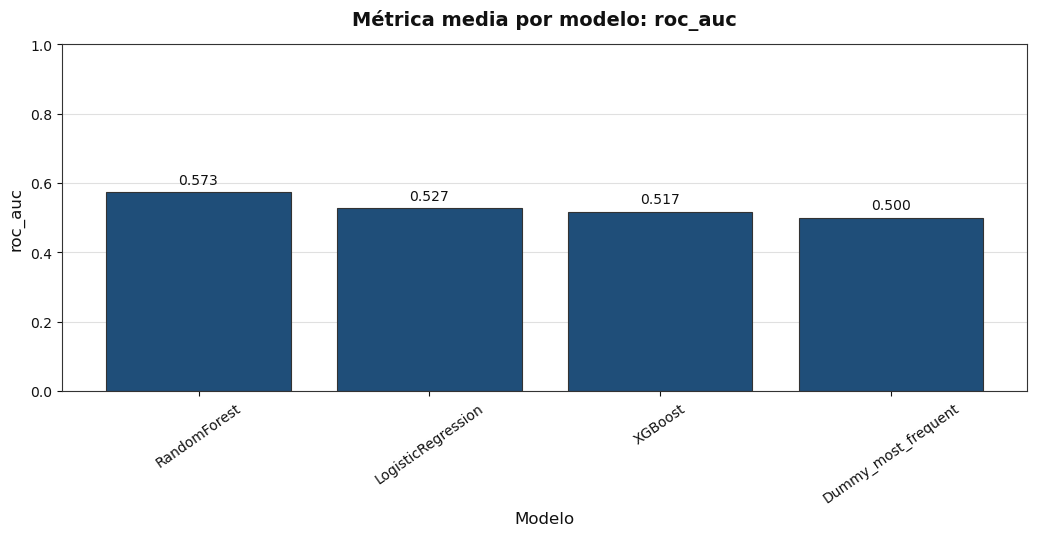

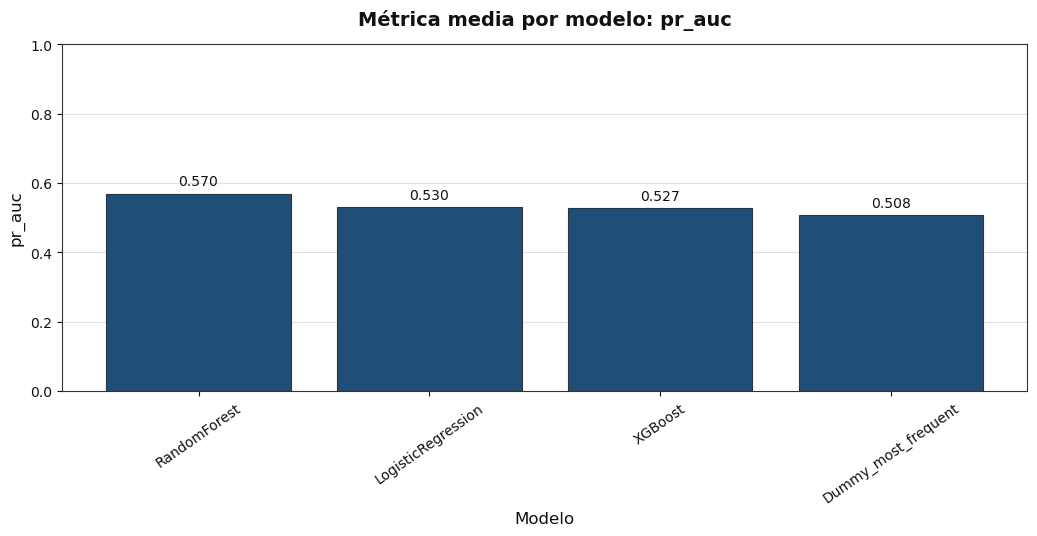

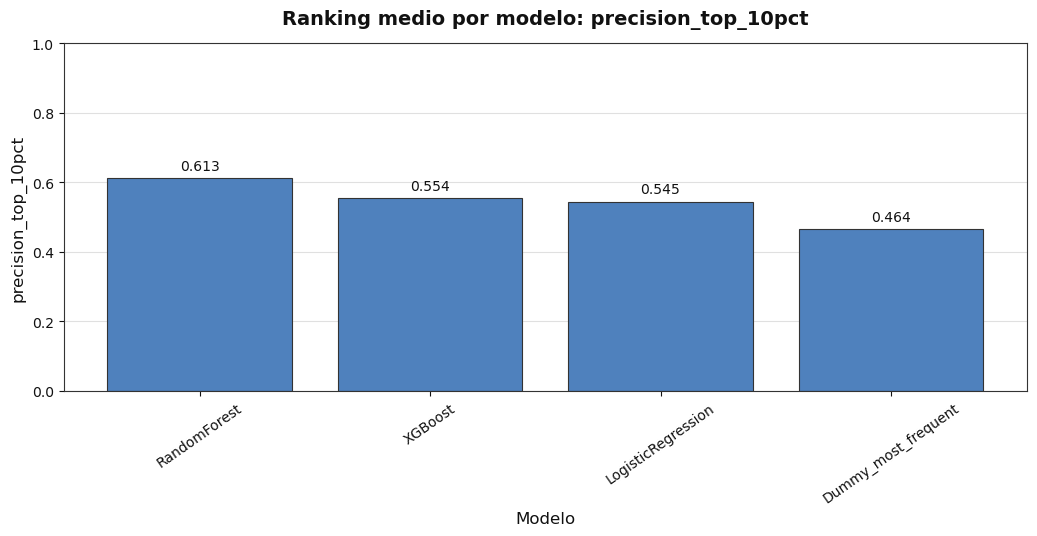

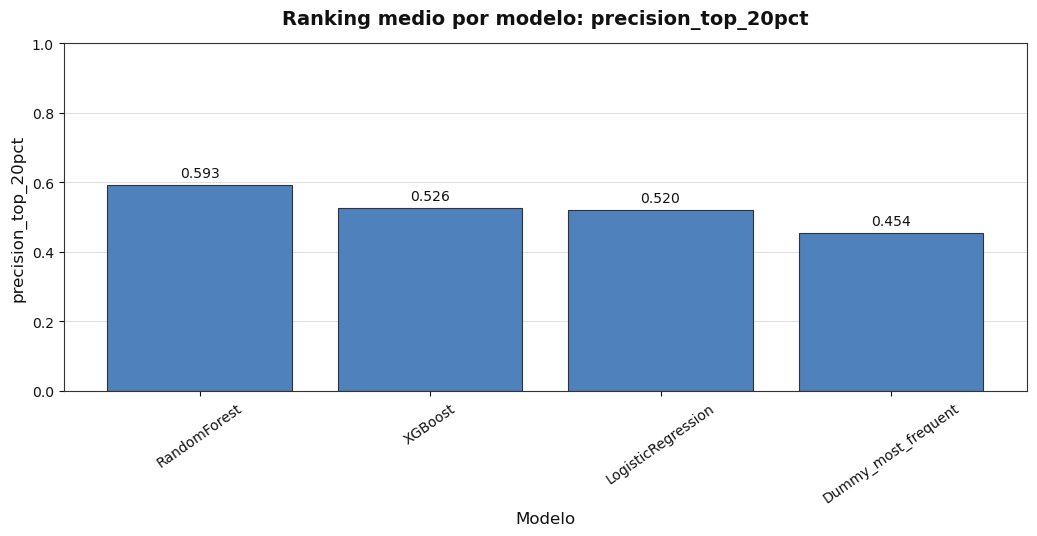

In [14]:
# Figuras de métricas medias por modelo con formato homogéneo y alto contraste
plot_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

for metric in plot_metrics:
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    tmp = metrics_mean.sort_values(metric, ascending=False).copy()
    bars = ax.bar(tmp["model"], tmp[metric], color=COLOR_BAR, edgecolor=COLOR_BORDER, linewidth=0.8)
    ax.set_title(f"Métrica media por modelo: {metric}", fontweight="bold", pad=14)
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=35)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=COLOR_TEXT
        )

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"fig_nb06_metric_{metric}_by_model.png", dpi=200, bbox_inches="tight")
    plt.show()

# Figuras de ranking: Precision@10% y Precision@20%
for metric in ["precision_top_10pct", "precision_top_20pct"]:
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    tmp = ranking_mean.sort_values(metric, ascending=False).copy()
    bars = ax.bar(tmp["model"], tmp[metric], color=COLOR_BAR_ALT, edgecolor=COLOR_BORDER, linewidth=0.8)
    ax.set_title(f"Ranking medio por modelo: {metric}", fontweight="bold", pad=14)
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=35)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=COLOR_TEXT
        )

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"fig_nb06_ranking_{metric}_by_model.png", dpi=200, bbox_inches="tight")
    plt.show()


## 14. Importancia de variables


,model,feature,importance
29,RandomForest,num__feat_regime_market_vol_20d_mean,0.215777
23,RandomForest,num__feat_regime_breadth_kumo_actual_alcista,0.069849
20,RandomForest,num__feat_regime_breadth_chikou_sobre_kumo,0.064487
24,RandomForest,num__feat_regime_breadth_kumo_futuro_alcista,0.050444
25,RandomForest,num__feat_regime_breadth_precio_sobre_kumo,0.049140
28,RandomForest,num__feat_regime_market_ret_5d_mean,0.043017
30,RandomForest,num__feat_regime_market_volume_rel_mean,0.041714
27,RandomForest,num__feat_regime_market_ret_20d_mean,0.040811
21,RandomForest,num__feat_regime_breadth_entry_events,0.037362
26,RandomForest,num__feat_regime_breadth_tenkan_sobre_kijun,0.035535


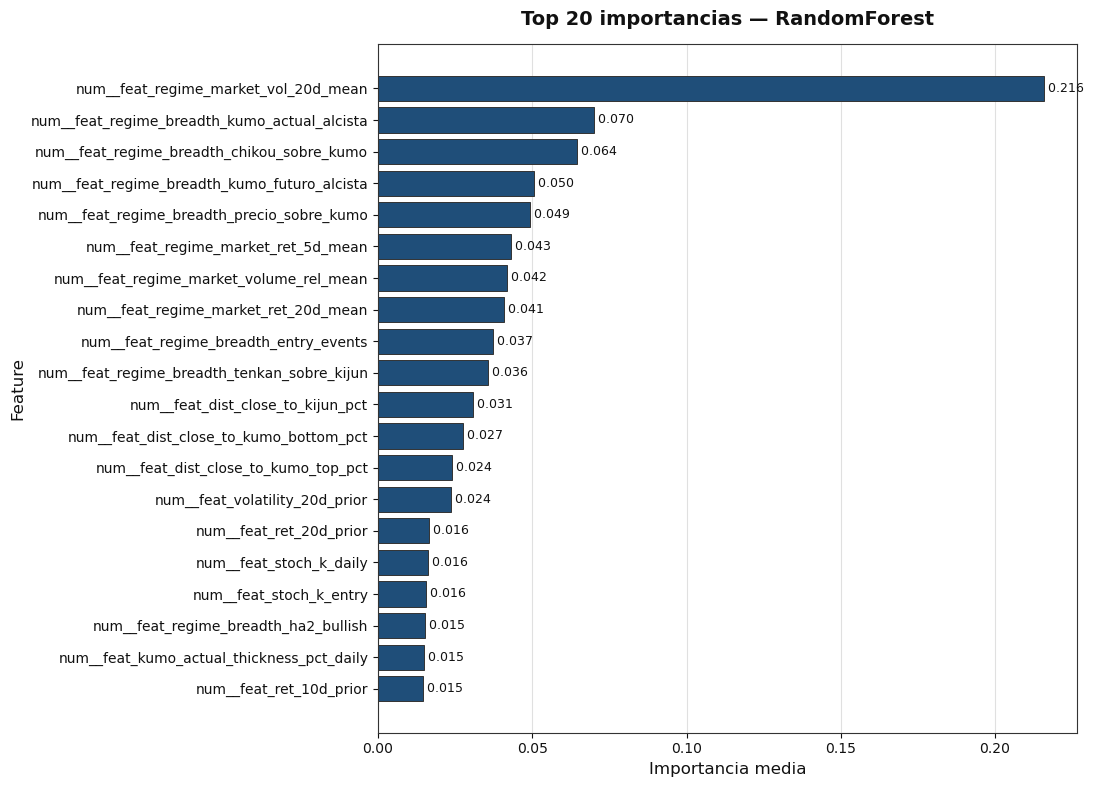

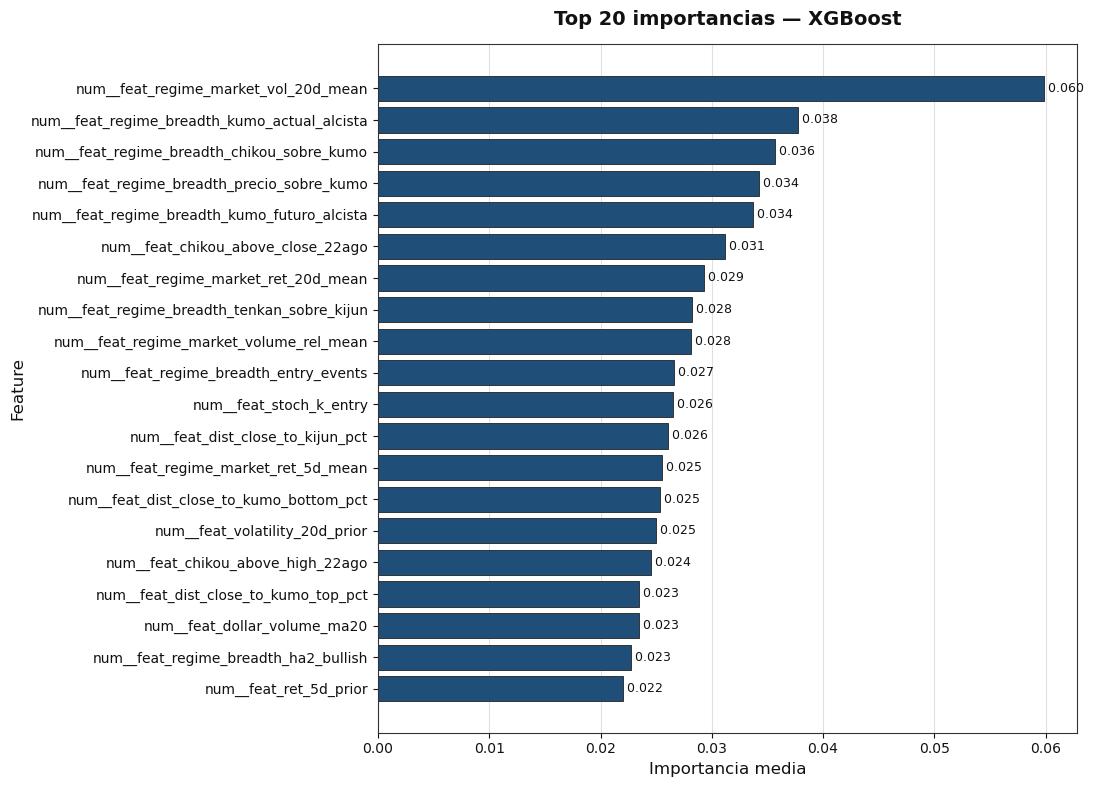

In [15]:
if feature_importance_df.empty:
    print("No hay importancias de variables disponibles.")
else:
    importance_mean = (
        feature_importance_df
        .groupby(["model", "feature"], as_index=False)["importance"]
        .mean()
        .sort_values(["model", "importance"], ascending=[True, False])
    )
    importance_mean.to_csv(OUTPUT_DIR / "feature_importance_mean_nb06.csv", index=False)

    display(importance_mean.groupby("model").head(20))

    for model_name in importance_mean["model"].unique():
        top_imp = importance_mean[importance_mean["model"] == model_name].head(20).sort_values("importance")
        fig, ax = plt.subplots(figsize=(11, 8))
        bars = ax.barh(top_imp["feature"], top_imp["importance"], color=COLOR_BAR, edgecolor=COLOR_BORDER, linewidth=0.7)
        ax.set_title(f"Top 20 importancias — {model_name}", fontweight="bold", pad=14)
        ax.set_xlabel("Importancia media")
        ax.set_ylabel("Feature")
        ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8, alpha=0.8)
        ax.set_axisbelow(True)

        for bar in bars:
            width = bar.get_width()
            ax.text(
                width,
                bar.get_y() + bar.get_height() / 2,
                f" {width:.3f}",
                va="center",
                fontsize=9,
                color=COLOR_TEXT
            )

        fig.tight_layout()
        fig.savefig(FIGURES_DIR / f"fig_nb06_feature_importance_{model_name}.png", dpi=200, bbox_inches="tight")
        plt.show()
